# What is the most optimal skills to learn for Data Analysts?

## Methodology:
 1. Group skills to determine median salary and likelihood of being in posting
 2. Visualise median salary vs percent skill demand
 3. Determine if certain technologies are more prevalent

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
# Data Cleaning:

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [4]:
role = 'Data Analyst'
country = 'United Kingdom'

In [5]:
df_DA_UK = df[(df['job_title'] == role) & (df['job_country'] == country)].copy()

In [7]:
df_DA_UK = df[df['job_country'] == country].copy().dropna(subset=['salary_year_avg'])

df_DA_UK_explode = df_DA_UK.explode('job_skills')

df_DA_UK_explode[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
1107,157500.0,python
1107,157500.0,numpy
1107,157500.0,pandas
1107,157500.0,scikit-learn
2602,51014.0,excel


In [10]:
df_DA_skills = df_DA_UK_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_DA_skills

,skill_count,median_salary
job_skills,,
python,169,111175.0
sql,160,105300.0
aws,92,131723.5
excel,50,89100.0
tableau,47,111175.0
...,...,...
sharepoint,1,100500.0
terminal,1,53014.0
trello,1,89100.0


In [11]:
DA_job_count = len(df_DA_UK)

df_DA_skills['skill_percent'] = (df_DA_skills['skill_count'] / DA_job_count) * 100

df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
python,169,111175.0,58.885017
sql,160,105300.0,55.749129
aws,92,131723.5,32.055749
excel,50,89100.0,17.421603
tableau,47,111175.0,16.376307
...,...,...,...
sharepoint,1,100500.0,0.348432
terminal,1,53014.0,0.348432
trello,1,89100.0,0.348432


In [13]:
skill_percent = 10

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
python,169,111175.0,58.885017
sql,160,105300.0,55.749129
aws,92,131723.5,32.055749
excel,50,89100.0,17.421603
tableau,47,111175.0,16.376307
spark,44,147500.0,15.331010
r,42,113360.5,14.634146
azure,39,131580.0,13.588850
gcp,33,132500.0,11.498258


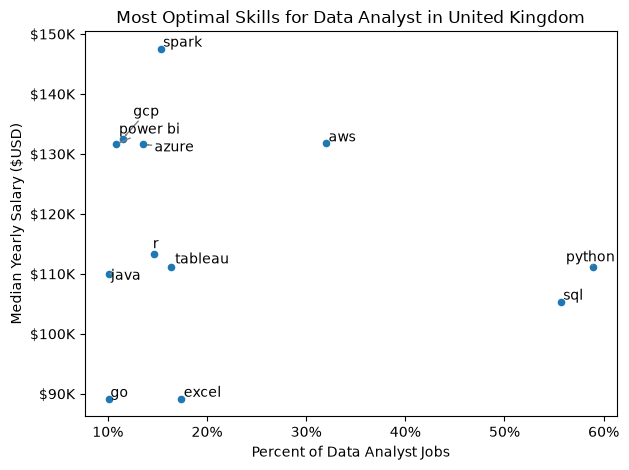

In [21]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_skills_high_demand.plot(kind="scatter", x="skill_percent", y="median_salary")


texts = []

for i, text in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], text))



adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw="1"))

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y / 1000)}K"))

plt.xlabel(f"Percent of {role} Jobs")
plt.ylabel("Median Yearly Salary ($USD)")
plt.title(f"Most Optimal Skills for {role} in {country}")

ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y / 1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [22]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technologies = {}
for row in df_technology:
    row = ast.literal_eval(row)

    for key, value in row.items():
        if key in technologies:
            technologies[key] += value
        else:
            technologies[key] = value

for key, value in technologies.items():
    technologies[key] = list(set(value))

technologies

{'analyst_tools': ['sap',
  'sheets',
  'nuix',
  'dax',
  'excel',
  'qlik',
  'sharepoint',
  'power bi',
  'spss',
  'powerbi',
  'outlook',
  'looker',
  'sas',
  'ssis',
  'word',
  'ms access',
  'datarobot',
  'cognos',
  'alteryx',
  'msaccess',
  'tableau',
  'powerpoint',
  'spreadsheet',
  'splunk',
  'esquisse',
  'ssrs',
  'visio',
  'microstrategy'],
 'programming': ['javascript',
  'powershell',
  'html',
  'sass',
  'lua',
  'python',
  'f#',
  'objective-c',
  'clojure',
  'java',
  't-sql',
  'go',
  'typescript',
  'vb.net',
  'nosql',
  'pascal',
  'mongodb',
  'php',
  'c',
  'bash',
  'assembly',
  'c++',
  'groovy',
  'dart',
  'apl',
  'erlang',
  'r',
  'no-sql',
  'sas',
  'golang',
  'visual basic',
  'delphi',
  'julia',
  'fortran',
  'mongo',
  'perl',
  'shell',
  'lisp',
  'sql',
  'css',
  'rust',
  'elixir',
  'matlab',
  'haskell',
  'ocaml',
  'kotlin',
  'c#',
  'crystal',
  'cobol',
  'vba',
  'scala',
  'solidity',
  'swift',
  'ruby',
  'visualba

In [25]:
df_technology = pd.DataFrame(list(technologies.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,sap
0,analyst_tools,sheets
0,analyst_tools,nuix
0,analyst_tools,dax
0,analyst_tools,excel
...,...,...
9,sync,webex
9,sync,ringcentral
9,sync,wire
9,sync,slack


In [28]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills' )

df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,169,111175.0,58.885017,programming,python
1,160,105300.0,55.749129,programming,sql
2,92,131723.5,32.055749,cloud,aws
3,50,89100.0,17.421603,analyst_tools,excel
4,47,111175.0,16.376307,analyst_tools,tableau
5,44,147500.0,15.331010,libraries,spark
6,42,113360.5,14.634146,programming,r
7,39,131580.0,13.588850,cloud,azure
8,33,132500.0,11.498258,cloud,gcp
9,31,131580.0,10.801394,analyst_tools,power bi


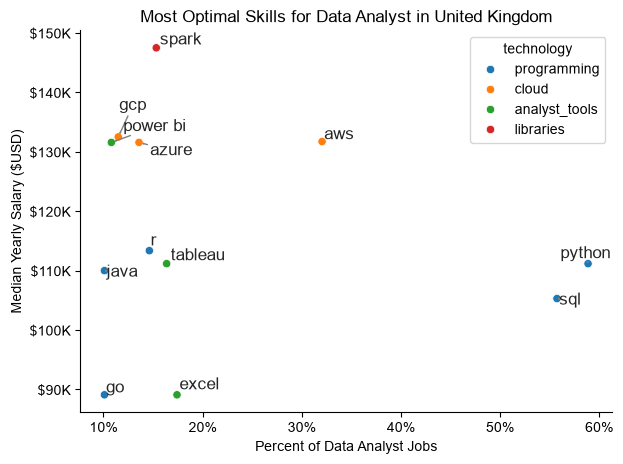

In [31]:
# df_plot.plot(kind="scatter", x="skill_percent", y="median_salary")
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style="ticks")

texts = []

for i, text in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], text))



adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw="1"))

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y / 1000)}K"))

plt.xlabel(f"Percent of {role} Jobs")
plt.ylabel("Median Yearly Salary ($USD)")
plt.title(f"Most Optimal Skills for {role} in {country}")

ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y / 1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()